<a href="https://colab.research.google.com/github/AlHartMos/IEU_courses/blob/main/simulating_and_modeling/3_Tests_of_Randomness_Excercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tests of Randomness

There are many ways to check if a sequence of numbers meets the requirments of randomness.



##Test 1: Visual Inspection of uniformity

Check if the numbers generated by the random number generator are "reasonably flat" by visually inspecting the histogram

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


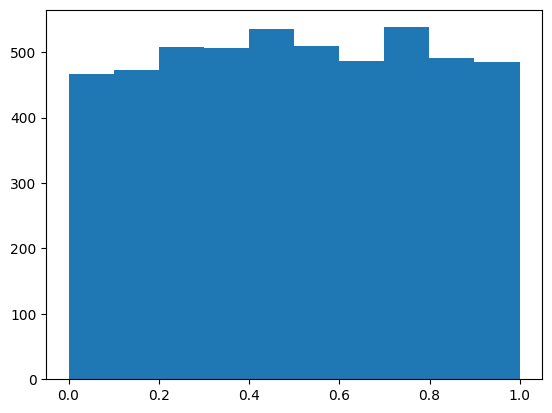

In [ ]:
#Set a seed
np.random.seed(2025)

#Generate a uniform random distribution and assign it to a variable
u = np.random.uniform(0, 1, 5000)

#Plot a histogram and show it
plt.hist(u)
plt.show()


#Test 2: Kolmogrov-Smirnov test of uniformity

although the histogram is quite informative, it is not a fairly formal method. On the other hand, we could do a hypothesis test that follows this form:

*  $H_0$: $u_i$ is uniform between zero and one, $i = 1,2,...$
*  $H_a$: $u_i$ is not uniform between zero and one, $i = 1,2,...$

If we reject the null hypothesis, which happens if the p-value of the test is very small (or smaller than a critical value $α$ of our choice), then we would say that, with a confidence level of $(1-α)$ * 100%, we have enough statistical evidence to reject the $H_0$.


In order to understand how the test works we need to briefly review the concept of empirical cumulative distribution function or ecdf. The ecdf $Fhat$ is the cumulative distribution function computed from a sequence of N numbers as

$ \hat{F}(t) = \dfrac{numbers \ in \ the \ sequence \le t}{N}$

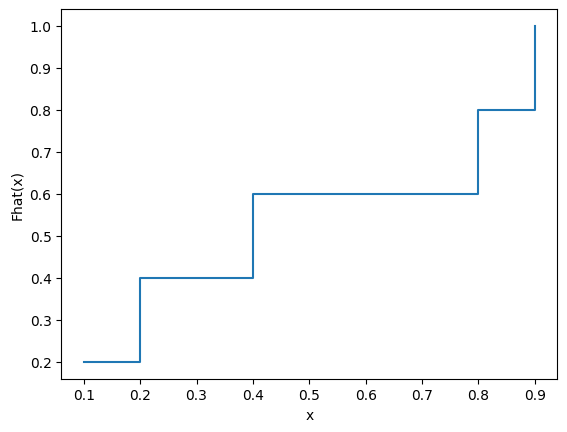

In [ ]:
# Create a vector of 5 values from 0.1 to 0.9
values = [0.1, 0.2, 0.4, 0.8, 0.9]

# sort the values
values.sort()

# calculate the ECDF. assign this to variable y
y = [i / len(values) for i in range(1, len(values) + 1)]

#assign values to x
x = values

# plot the ECDF using a step function and show the plot
plt.step(x, y, where="post")
plt.xlabel("x")
plt.ylabel("Fhat(x)")
plt.show()

What does the ECDF look like for a series of numbers that are uniform?

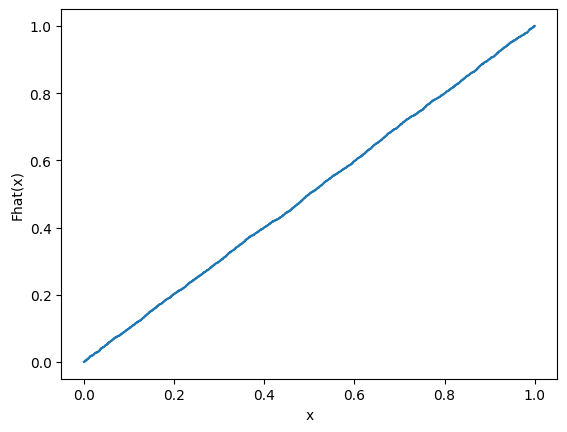

In [ ]:
# generate normal values similar to previous
values = np.random.uniform(0, 1, 5000)

# sort the values
values.sort()

# calculate the ECDF
y = [i / len(values) for i in range(1, len(values) + 1)]
x = values

# plot the ECDF
plt.step(x, y, where="post")
plt.xlabel("x")
plt.ylabel("Fhat(x)")
plt.show()

The idea behind the Kolmogorov-Smirnov test is to quantify how similar the ecdf computed from a sequence of data is to the one of the uniform distribution which is represented by a straight line.

The test formally embeds this idea of similarity between the ecdf and the cdf of the uniform in a test of hypothesis. The function `stats.kstest` from the `scipy` library implements this test in Python. For the two sequences `u1` and `u2` of the slide 10, the test can be implemented as following:

In [ ]:
#from the scipy library import the stats package
from scipy import stats

#set a seed
np.random.seed(2025)

# create 2 sets of random numbers, 1 uniform and another normal
u1 = np.random.uniform(0, 1, 5000)
u2 = np.random.normal(0, 1, 5000)

# perform the Kolmogorov-Smirnov test
D, p_value = stats.kstest(u1, 'uniform')

# print the results of the first KS test
print("Results for u1 KS test")
print("D-statistic: ", D) # Maximum distance from the uniform distribution
print("p-value: ", p_value) # Potential to reject the null hypothesis (being ui is NOT uniform)

# perform the Kolmogorov-Smirnov test for the normal distribution
D, p_value = stats.kstest(u2, 'uniform')

# print the results of the second KS test
print()
print("Results for u2 KS test")
print("D-statistic: ", D) # D-statistic = 0.503; (Large distance between uniform distribution and normal distribution points)
print("p-value: ", p_value) # p_value = 0.0; (Reject the null hypothesis: The two samples come from different distributions)

Results for u1 KS test
D-statistic:  0.013095470715386415
p-value:  0.3548086009833509

Results for u2 KS test
D-statistic:  0.503
p-value:  0.0


Let us check what the ECDF looks like for u1 and u2, out of curiosity.

Text(0, 0.5, 'Fhat(x)')

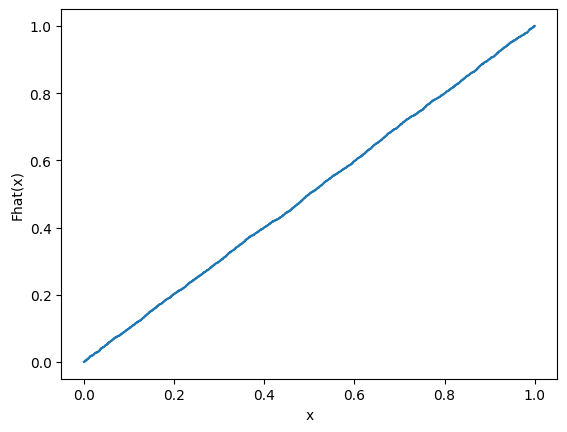

In [ ]:
# sort the values of u1
u1.sort()

# calculate the ECDF
y = [i / len(values) for i in range(1, len(values) + 1)]
x = values

# plot the ECDF for u1 and show it
plt.step(x, y, where='post')
plt.xlabel('x')
plt.ylabel('Fhat(x)')

Text(0, 0.5, 'Fhat(x)')

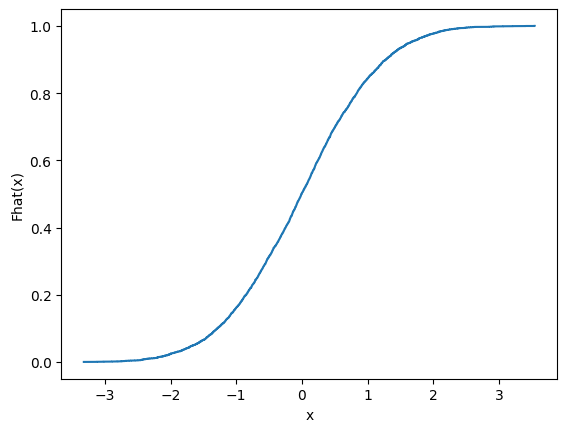

In [ ]:
# sort the values for u2
u2.sort()

# calculate the ECDF
y = [i / len(u2) for i in range (1, len(u2) + 1)]
x = u2

# plot the ECDF for u2 and show it
plt.step(x, y, where='post')
plt.xlabel('x')
plt.ylabel('Fhat(x)')


u2 is very clearly not uniform.

Note that the K-S test has many applications, not just checking if the distribution is uniform. It can also be used to check normality or exponential distributions as well. You can read more if you search the scipy user notes

#Test 3: Tests of Independence

The second requirement that a sequence of pseudo-random numbers must have is independence. We will consider tests of the form:

$H0$: $u1$ ,..., $uN$ are independent

$Ha$: $u1$ ,..., $uN$ are not independent

So the $H0$ is that the sequence is of independent numbers against the Ha that they are not.

If the p-value of such a test is smaller than ɑ we would then reject the H0 of independence.

we could compute the correlation between $(u1, u1+k)$, $(u2, u2+k)$,..., $(uN-k, uN)$ between each number in the sequence and the one k-positions ahead. This is what we call autocorrelation of lag k.

If autocorrelations of several lags are close to zero, this gives an indication that the data is independent. If the autocorrelation at some lags is big, then there is an indication of dependence in the sequence of random numbers.

Autocorrelations are computed and plotted in Python using the autocorrelation_plot function from pandas.


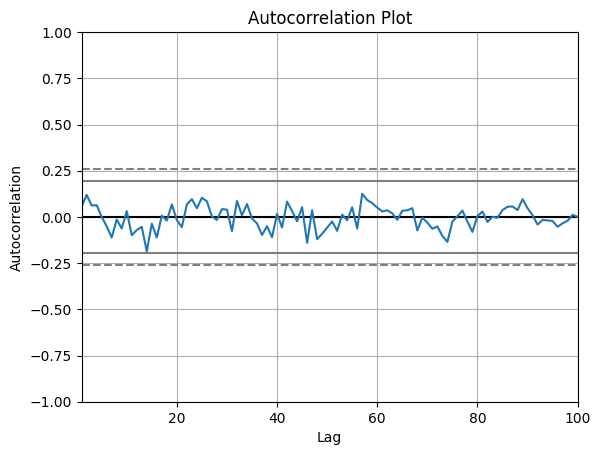

In [ ]:
#import pandas as pd, matplotlib.pyplot as plt, and numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# create a sample of random uniform numbers, say 100, assign to variable "sample"
sample = np.random.uniform(0, 1, 100)

# create a DataFrame from the sample and call it df
df = pd.DataFrame(sample, columns=['values'])

# create the autocorrelation plot
pd.plotting.autocorrelation_plot(df['values'])

# add a title and show the plot
plt.title("Autocorrelation Plot")
plt.show()


The blue line is the autocorrelation at several lags, while the dashed grey lines are confidence bands:
If the line is within the bands it means that we fail to reject the H0: that the values are independent.

Since the line is always within the confidence bands, we have enough statistical evidence to say that all autocorrelations are not different from zero and consequently that the data is independent.

What if we had a distribution that is uniform but not independent?

#Test 4: Uniform but not Independent

[0.1 0.1 0.1 0.1 0.2 0.2 0.2 0.2 0.3 0.3 0.3 0.3 0.4 0.4 0.4 0.4 0.5 0.5
 0.5 0.5 0.6 0.6 0.6 0.6 0.7 0.7 0.7 0.7 0.8 0.8 0.8 0.8 0.9 0.9 0.9 0.9
 1.  1.  1.  1.  0.1 0.1 0.1 0.1 0.2 0.2 0.2 0.2 0.3 0.3 0.3 0.3 0.4 0.4
 0.4 0.4 0.5 0.5 0.5 0.5 0.6 0.6 0.6 0.6 0.7 0.7 0.7 0.7 0.8 0.8 0.8 0.8
 0.9 0.9 0.9 0.9 1.  1.  1.  1.  0.1 0.1 0.1 0.1 0.2 0.2 0.2 0.2 0.3 0.3
 0.3 0.3 0.4 0.4 0.4 0.4 0.5 0.5 0.5 0.5 0.6 0.6 0.6 0.6 0.7 0.7 0.7 0.7
 0.8 0.8 0.8 0.8 0.9 0.9 0.9 0.9 1.  1.  1.  1.  0.1 0.1 0.1 0.1 0.2 0.2
 0.2 0.2 0.3 0.3 0.3 0.3 0.4 0.4 0.4 0.4 0.5 0.5 0.5 0.5 0.6 0.6 0.6 0.6
 0.7 0.7 0.7 0.7 0.8 0.8 0.8 0.8 0.9 0.9 0.9 0.9 1.  1.  1.  1.  0.1 0.1
 0.1 0.1 0.2 0.2 0.2 0.2 0.3 0.3 0.3 0.3 0.4 0.4 0.4 0.4 0.5 0.5 0.5 0.5
 0.6 0.6 0.6 0.6 0.7 0.7 0.7 0.7 0.8 0.8 0.8 0.8 0.9 0.9 0.9 0.9 1.  1.
 1.  1.  0.1 0.1 0.1 0.1 0.2 0.2 0.2 0.2 0.3 0.3 0.3 0.3 0.4 0.4 0.4 0.4
 0.5 0.5 0.5 0.5 0.6 0.6 0.6 0.6 0.7 0.7 0.7 0.7 0.8 0.8 0.8 0.8 0.9 0.9
 0.9 0.9 1.  1.  1.  1.  0.1 0.1 0.1 0.1 0.2 0.2 0.2

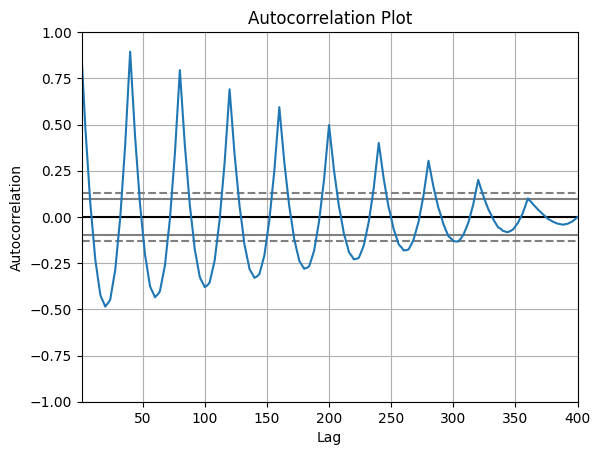

In [ ]:

#creating a sequence of repeating numbers (400 observations)
u3 = np.array(list(np.repeat(np.arange(1, 11), repeats=4))*10)/10 # Series of values from 0.1, 1.0 repeated 40 times

#print u3 and u3.size to confirm
print(u3)
print(u3.size)

#adding random normal distribution noise to the repeating sequence
u3 = u3 + np.random.normal(0, 0.02, size=400)

#this is to normalize the sequence between 0 and 1 but is not strictly needed
u3 = (u3 - np.min(u3)) / (np.max(u3) - np.min(u3))

#print u3
print(u3)
print(u3.size)

#assign u3 to a data frame
df = pd.DataFrame(u3, columns=['values'])

#plot the df using autocorrelation_plot
pd.plotting.autocorrelation_plot(df['values'])
plt.title("Autocorrelation Plot")
plt.show()

(array([42., 38., 40., 41., 39., 40., 40., 37., 42., 41.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

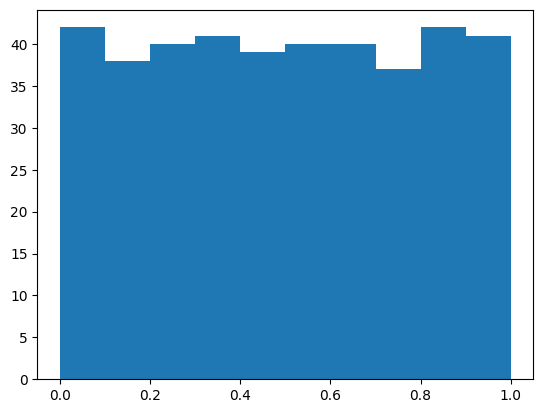

In [ ]:
#plot a histogram of u3
plt.hist(u3)

In [ ]:
# perform the Kolmogorov-Smirnov test  for u3
D, p_value = stats.kstest(u3, 'uniform')

# print the results
print("Results for u3 KS test: ")
print("D-statistic: ", D)
print("p-value: ", p_value)

Results for u3 KS test: 
D-statistic:  0.04169771929352589
p-value:  0.477315909162652


So we can confirm that for sequence u3


1.   we reject the null hypothesis of independence (and so accept that the distribution is dependent with 95% confidence)
2.   we fail to reject the null hypothesis of uniformity because the p-value is larger than 0.05 (the distribution is uniform with 95% confidence)



#Test 5: Test of Independence with ACF

A test of hypothesis for independence can be created by checking if any of the autocorrelations up to a specific lag are different from zero. This is could be done by using the function `q_stat` from the `statsmodels.tsa.stattools` module in Python.

We have to calculate the **autocorrelation function (acf)**, so then we can apply the Box test to the values of the autocorrelation function in different lags (10 is usually sufficient).

Let’s compute it for the two sequences u1 and u2 that we have defined before.


In [ ]:
import statsmodels.tsa.stattools as stattools

#recreating the distributions
u1 = np.random.uniform(0, 1, 400) #smaller size just as an example

u2 = np.random.normal(0, 1, 400)

u3 = np.array(list(np.repeat(np.arange(1, 11), repeats=4))*10)/10
u3 = u3 + np.random.normal(0, 0.02, size=400)
u3 = (u3 - np.min(u3)) / (np.max(u3) - np.min(u3))

acf, confint = stattools.acf(u1, nlags=10, alpha=0.05) # For class lag=10 and alpha=0.05 is sufficient
lbvalue, pvalue = stattools.q_stat(acf[1:], len(u2))

print("u1 results for the Box test with 10 lags")
print("p-value:", pvalue) # p-values are sufficently large, so we fail to reject the null hypothesis

u1 results for the Box test with 10 lags
p-value: [0.30202824 0.42686192 0.52192071 0.68612699 0.78776038 0.85328507
 0.9105508  0.81747437 0.75618257 0.77390811]


In [ ]:
acf, confint = stattools.acf(u2, nlags=10, alpha=0.05)
lbvalue, pvalue = stattools.q_stat(acf[1:], len(u2))

print("u2 results for the Box test with 10 lags")
print("p-value:", pvalue)


u2 results for the Box test with 10 lags
p-value: [0.97360993 0.17164882 0.04719903 0.08728752 0.14151239 0.14618775
 0.1080541  0.13876494 0.13856767 0.16819666]


In [ ]:
acf, confint = stattools.acf(u3, nlags=10, alpha=0.05)
lbvalue, pvalue = stattools.q_stat(acf[1:], len(u3))

print("u3 results for the Box test with 10 lags")
print("p-value:", pvalue) # p-values are very small, accept the null hypothesis

u3 results for the Box test with 10 lags
p-value: [3.62959835e-068 2.02748640e-114 2.50763349e-145 4.29719414e-164
 2.74049000e-175 1.40327946e-180 4.47439234e-182 1.90697419e-181
 2.04219016e-180 5.87164748e-180]
